In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv('weight-height.csv')

In [3]:
data.shape

(10000, 3)

In [4]:
data.head()

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Gender  10000 non-null  object 
 1   Height  10000 non-null  float64
 2   Weight  10000 non-null  float64
dtypes: float64(2), object(1)
memory usage: 234.5+ KB


In [6]:
data.isnull().mean()

,0
Gender,0.0
Height,0.0
Weight,0.0


{'whiskers': [<matplotlib.lines.Line2D at 0x7c34b24c01d0>,
 'caps': [<matplotlib.lines.Line2D at 0x7c34b24c0830>,
 'boxes': [<matplotlib.lines.Line2D at 0x7c34c3dc8230>],
 'medians': [<matplotlib.lines.Line2D at 0x7c34b24c0ec0>],
 'fliers': [<matplotlib.lines.Line2D at 0x7c34b24c11f0>],
 'means': []}

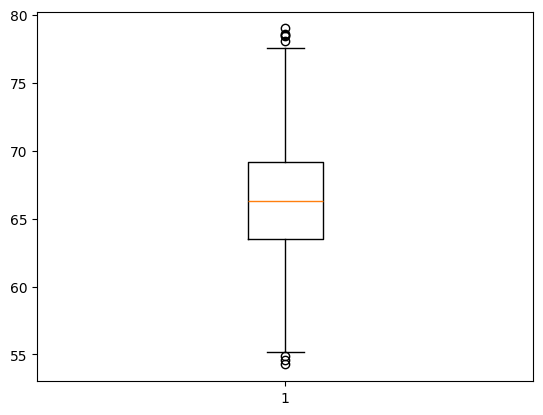

In [7]:
plt.boxplot(data['Height'])

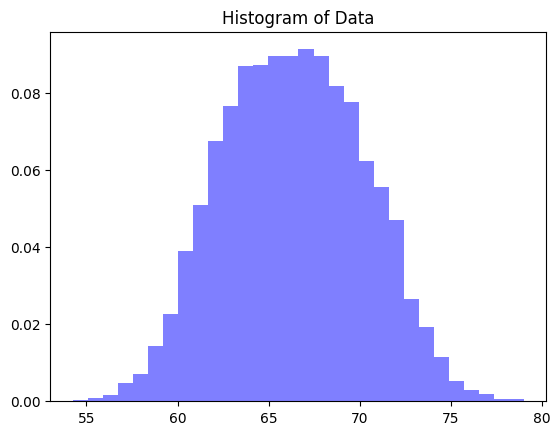

In [11]:
plt.hist(data['Height'], bins=30, density=True, alpha=0.5, color='blue')
plt.title('Histogram of Data')
plt.show()

<Axes: ylabel='Density'>

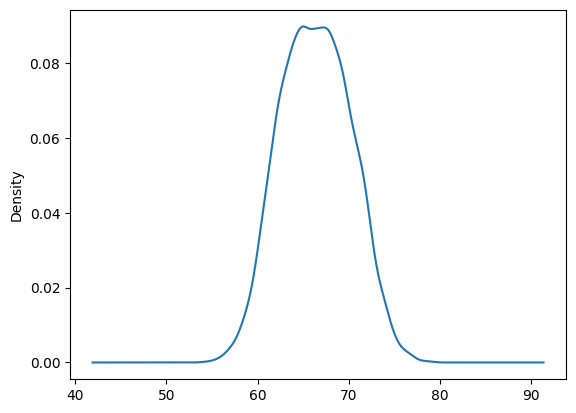

In [12]:
data['Height'].plot(kind='kde')

In [13]:
print("Mean value of height",data['Height'].mean())
print("Std value of height",data['Height'].std())
print("Min value of height",data['Height'].min())
print("Max value of height",data['Height'].max())

Mean value of height 66.36755975482124
Std value of height 3.8475281207732324
Min value of height 54.2631333250971
Max value of height 78.9987423463896


In [14]:
# Finding the boundary values
print("Highest allowed",data['Height'].mean() + 3*data['Height'].std())
print("Lowest allowed",data['Height'].mean() - 3*data['Height'].std())

Highest allowed 77.91014411714094
Lowest allowed 54.82497539250154


In [15]:
# Finding the outliers
data[(data['Height'] > 77.91) | (data['Height'] < 54.82)]

,Gender,Height,Weight
994,Male,78.095867,255.690835
1317,Male,78.462053,227.342565
2014,Male,78.998742,269.989699
3285,Male,78.528210,253.889004
3757,Male,78.621374,245.733783
6624,Female,54.616858,71.393749
9285,Female,54.263133,64.700127


In [16]:
# Trimming

new_df = data[(data['Height'] < 77.91) & (data['Height'] > 54.82)]
new_df

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801
...,...,...,...
9995,Female,66.172652,136.777454
9996,Female,67.067155,170.867906
9997,Female,63.867992,128.475319
9998,Female,69.034243,163.852461


In [17]:
# Approach 2

# Calculating the Zscore

data['height_zscore'] = (data['Height'] - data['Height'].mean())/data['Height'].std()
                        # X            -    MEAN                /     STD

In [18]:
data.head()

,Gender,Height,Weight,height_zscore
0,Male,73.847017,241.893563,1.943964
1,Male,68.781904,162.310473,0.627505
2,Male,74.110105,212.740856,2.012343
3,Male,71.730978,220.042470,1.393991
4,Male,69.881796,206.349801,0.913375


In [19]:
data[data['height_zscore']  > 3]

,Gender,Height,Weight,height_zscore
994,Male,78.095867,255.690835,3.048271
1317,Male,78.462053,227.342565,3.143445
2014,Male,78.998742,269.989699,3.282934
3285,Male,78.528210,253.889004,3.160640
3757,Male,78.621374,245.733783,3.184854


In [20]:
data[data['height_zscore']  < -3]

,Gender,Height,Weight,height_zscore
6624,Female,54.616858,71.393749,-3.054091
9285,Female,54.263133,64.700127,-3.146027


In [21]:
data[(data['height_zscore']  > 3) | (data['height_zscore']  < -3)]

,Gender,Height,Weight,height_zscore
994,Male,78.095867,255.690835,3.048271
1317,Male,78.462053,227.342565,3.143445
2014,Male,78.998742,269.989699,3.282934
3285,Male,78.528210,253.889004,3.160640
3757,Male,78.621374,245.733783,3.184854
6624,Female,54.616858,71.393749,-3.054091
9285,Female,54.263133,64.700127,-3.146027


In [23]:
# Trimming
new_data  = data[(data['height_zscore']  < 3) & (data['height_zscore']  > -3)]

In [24]:
new_data

,Gender,Height,Weight,height_zscore
0,Male,73.847017,241.893563,1.943964
1,Male,68.781904,162.310473,0.627505
2,Male,74.110105,212.740856,2.012343
3,Male,71.730978,220.042470,1.393991
4,Male,69.881796,206.349801,0.913375
...,...,...,...,...
9995,Female,66.172652,136.777454,-0.050658
9996,Female,67.067155,170.867906,0.181830
9997,Female,63.867992,128.475319,-0.649655
9998,Female,69.034243,163.852461,0.693090


**Capping**

In [25]:
upper_limit = data['Height'].mean() + 3*data['Height'].std() # 77.91
lower_limit = data['Height'].mean() - 3*data['Height'].std() #54.82

In [26]:
lower_limit

np.float64(54.82497539250154)

In [27]:
upper_limit

np.float64(77.91014411714094)

In [28]:
for i in range(len(data['Height'])):
    # If the value exceeds the upper limit, replace it with the upper limit
    if data['Height'][i] > upper_limit:
        data['Height'][i] = upper_limit
    # If the value is below the lower limit, replace it with the lower limit
    elif data['Height'][i] < lower_limit:
        data['Height'][i] = lower_limit
    # Otherwise, keep the original value
    else:
        pass

/tmp/ipykernel_761/3770085591.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['Height'][i] = upper_limit
/tmp/ipykernel_761/3770085591.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['Height'][i] = upper_limit
/tmp/ipykernel_761/3770085591.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['Height'][i] = upper_limit
/tmp/ipykernel_761/3770085591.py:4: SettingWithCopyWarning: 
A value is trying to be set on a cop

In [29]:
specific_record = data.iloc[9285]
print(specific_record)

Gender              Female
Height           54.824975
Weight           64.700127
height_zscore    -3.146027
Name: 9285, dtype: object


In [30]:
data.shape

(10000, 4)